In [3]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🔽 Выберите файл GlobalTemperatures.csv на вашем компьютере")
uploaded = files.upload()

🔽 Выберите файл GlobalTemperatures.csv на вашем компьютере


Saving GlobalTemperatures.csv to GlobalTemperatures (1).csv


In [4]:
# Получаем имя загруженного файла
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("✅ Размер датасета (строки, колонки):", df.shape)
print("\n📊 Первые 5 строк:")
df.head()

✅ Размер датасета (строки, колонки): (3192, 9)

📊 Первые 5 строк:


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   object 
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), object(1)
memory usage: 224.6+ KB


In [6]:
print("📉 Пропуски в каждой колонке:")
df.isnull().sum()

📉 Пропуски в каждой колонке:


,0
dt,0
LandAverageTemperature,12
LandAverageTemperatureUncertainty,12
LandMaxTemperature,1200
LandMaxTemperatureUncertainty,1200
LandMinTemperature,1200
LandMinTemperatureUncertainty,1200
LandAndOceanAverageTemperature,1200
LandAndOceanAverageTemperatureUncertainty,1200


In [7]:
df.describe()

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
count,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
std,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838,1.274093,0.073587
min,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000,12.475000,0.042000
25%,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000,14.047000,0.063000
50%,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000,15.251000,0.122000
75%,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250,16.396250,0.151000
max,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000,17.611000,0.457000


In [8]:
# Конвертируем дату
df['dt'] = pd.to_datetime(df['dt'])

print(f"📅 Диапазон дат: с {df['dt'].min()} по {df['dt'].max()}")

📅 Диапазон дат: с 1750-01-01 00:00:00 по 2015-12-01 00:00:00


In [9]:
# Удаляем строки без температуры
df_clean = df.dropna(subset=['LandAverageTemperature'])

print(f"📊 Было строк: {len(df)}")
print(f"📊 Стало строк: {len(df_clean)}")
print(f"🗑️ Удалено строк: {len(df) - len(df_clean)}")

📊 Было строк: 3192
📊 Стало строк: 3180
🗑️ Удалено строк: 12


In [10]:
# Проверяем пропуски в других колонках после очистки
print("Остались ли пропуски?")
print(df_clean.isnull().sum())

Остались ли пропуски?
dt                                              0
LandAverageTemperature                          0
LandAverageTemperatureUncertainty               0
LandMaxTemperature                           1188
LandMaxTemperatureUncertainty                1188
LandMinTemperature                           1188
LandMinTemperatureUncertainty                1188
LandAndOceanAverageTemperature               1188
LandAndOceanAverageTemperatureUncertainty    1188
dtype: int64


In [11]:
# Извлекаем год, месяц, день из даты
df_clean['year'] = df_clean['dt'].dt.year
df_clean['month'] = df_clean['dt'].dt.month
df_clean['day_of_year'] = df_clean['dt'].dt.dayofyear

# Создаем сезон (0-зима, 1-весна, 2-лето, 3-осень)
df_clean['season'] = df_clean['month'].map({
    12:0, 1:0, 2:0,      # Зима
    3:1, 4:1, 5:1,       # Весна
    6:2, 7:2, 8:2,       # Лето
    9:3, 10:3, 11:3      # Осень
})

print("Новые колонки добавлены!")
df_clean[['dt', 'year', 'month', 'day_of_year', 'season']].head()

Новые колонки добавлены!


/tmp/ipykernel_7210/2062810867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['year'] = df_clean['dt'].dt.year
/tmp/ipykernel_7210/2062810867.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['month'] = df_clean['dt'].dt.month
/tmp/ipykernel_7210/2062810867.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

,dt,year,month,day_of_year,season
0,1750-01-01,1750,1,1,0
1,1750-02-01,1750,2,32,0
2,1750-03-01,1750,3,60,1
3,1750-04-01,1750,4,91,1
4,1750-05-01,1750,5,121,1


In [12]:
# Сортируем по дате
df_sorted = df_clean.sort_values('dt')
df_sorted.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty,year,month,day_of_year,season
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN,1750,1,1,0
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN,1750,2,32,0
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN,1750,3,60,1
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN,1750,4,91,1
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN,1750,5,121,1


In [13]:
# Создаем лаги (сдвиги температуры на 1, 2, 3 и 12 месяцев назад)
# Сначала убедимся, что данные идут подряд по месяцам
df_sorted['temp_lag1'] = df_sorted['LandAverageTemperature'].shift(1)
df_sorted['temp_lag2'] = df_sorted['LandAverageTemperature'].shift(2)
df_sorted['temp_lag3'] = df_sorted['LandAverageTemperature'].shift(3)
df_sorted['temp_lag12'] = df_sorted['LandAverageTemperature'].shift(12)

# Удаляем строки с NaN (первые 12 строк не будут иметь лагов)
df_final = df_sorted.dropna()

print(f"После создания лагов: {len(df_final)} строк")
print("Пример с лагами:")
df_final[['dt', 'LandAverageTemperature', 'temp_lag1', 'temp_lag12']].head(15)

После создания лагов: 1992 строк
Пример с лагами:


,dt,LandAverageTemperature,temp_lag1,temp_lag12
1200,1850-01-01,0.749,1.923,1.941
1201,1850-02-01,3.071,0.749,2.638
1202,1850-03-01,4.954,3.071,5.302
1203,1850-04-01,7.217,4.954,7.028
1204,1850-05-01,10.004,7.217,10.159
1205,1850-06-01,13.150,10.004,13.000
1206,1850-07-01,14.492,13.150,14.458
1207,1850-08-01,14.039,14.492,13.603
1208,1850-09-01,11.505,14.039,11.093
1209,1850-10-01,8.091,11.505,8.890


In [14]:
print("Финальный размер датасета:", df_final.shape)
print("\nКолонки:")
print(df_final.columns.tolist())
print("\nСтатистика по целевой переменной:")
df_final['LandAverageTemperature'].describe()

Финальный размер датасета: (1992, 17)

Колонки:
['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty', 'year', 'month', 'day_of_year', 'season', 'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag12']

Статистика по целевой переменной:


,LandAverageTemperature
count,1992.000000
mean,8.571583
std,4.263193
min,0.404000
25%,4.430000
50%,8.850500
75%,12.858500
max,15.482000


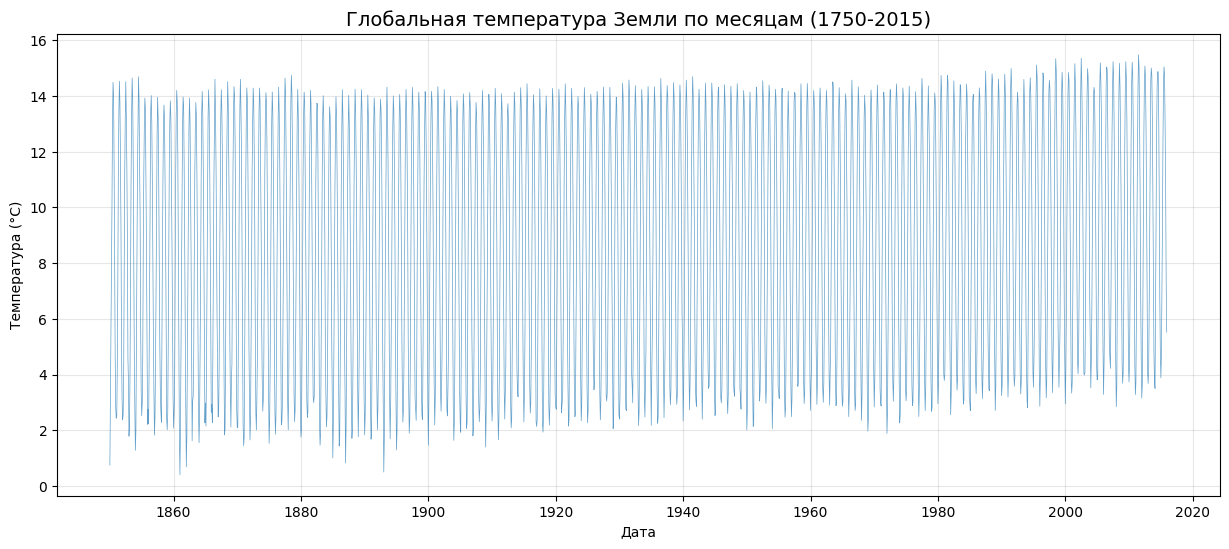

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(df_final['dt'], df_final['LandAverageTemperature'], linewidth=0.5, alpha=0.7)
plt.title('Глобальная температура Земли по месяцам (1750-2015)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True, alpha=0.3)
plt.show()

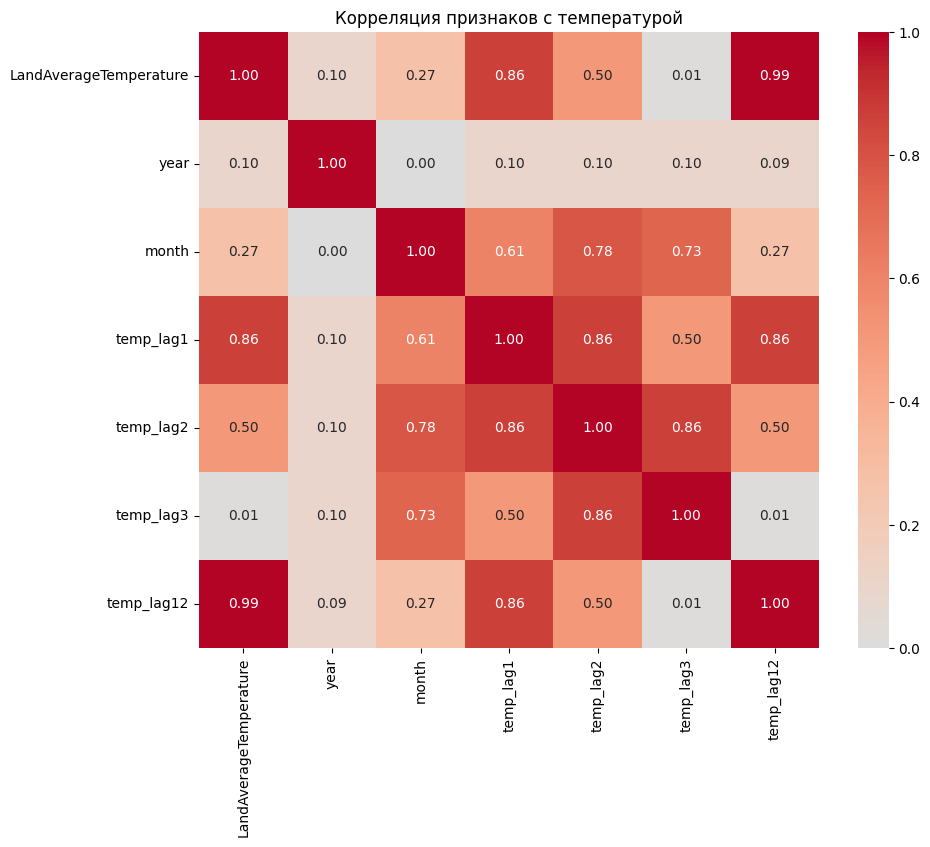


Корреляция признаков с LandAverageTemperature:
LandAverageTemperature    1.000000
temp_lag12                0.993606
temp_lag1                 0.863679
temp_lag2                 0.502827
month                     0.265959
year                      0.095921
temp_lag3                 0.011743
Name: LandAverageTemperature, dtype: float64


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Выбираем числовые колонки для корреляции
corr_cols = ['LandAverageTemperature', 'year', 'month', 'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag12']
corr_matrix = df_final[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция признаков с температурой')
plt.show()

# Выводим корреляцию с целевой переменной
print("\nКорреляция признаков с LandAverageTemperature:")
print(corr_matrix['LandAverageTemperature'].sort_values(ascending=False))

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Фиксируем seed
SEED = 42
np.random.seed(SEED)

# Разделение по времени
df_final = df_final.sort_values('dt')

train = df_final[df_final['year'] <= 2000]
val = df_final[(df_final['year'] > 2000) & (df_final['year'] <= 2010)]
test = df_final[df_final['year'] > 2010]

print(f"Train: {len(train)} строк")
print(f"Val: {len(val)} строк")
print(f"Test: {len(test)} строк")

# Признаки (используем лучшие из корреляции)
feature_cols = ['year', 'month', 'temp_lag1', 'temp_lag2', 'temp_lag12']
target_col = 'LandAverageTemperature'

X_train = train[feature_cols]
y_train = train[target_col]
X_val = val[feature_cols]
y_val = val[target_col]

# 1. Linear Regression (Baseline)
print("\n" + "="*50)
print("BASELINE: Linear Regression")
print("="*50)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)

mae_lr = mean_absolute_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr = r2_score(y_val, y_pred_lr)

print(f"MAE: {mae_lr:.4f} °C")
print(f"RMSE: {rmse_lr:.4f} °C")
print(f"R²: {r2_lr:.4f}")

# 2. Random Forest
print("\n" + "="*50)
print("Random Forest Regressor")
print("="*50)

rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print(f"MAE: {mae_rf:.4f} °C")
print(f"RMSE: {rmse_rf:.4f} °C")
print(f"R²: {r2_rf:.4f}")

# Сравнение
print("\n" + "="*50)
print("СРАВНЕНИЕ")
print("="*50)
print(f"Random Forest лучше Linear Regression на {mae_lr - mae_rf:.4f} °C (MAE)")

# Наивный прогноз
naive_pred = [y_train.mean()] * len(y_val)
naive_mae = mean_absolute_error(y_val, naive_pred)
print(f"\nНаивный прогноз (среднее): MAE = {naive_mae:.4f} °C")
print(f"Linear Regression лучше наивного на {naive_mae - mae_lr:.4f} °C")

Train: 1812 строк
Val: 120 строк
Test: 60 строк

BASELINE: Linear Regression
MAE: 0.3292 °C
RMSE: 0.4146 °C
R²: 0.9897

Random Forest Regressor
MAE: 0.4489 °C
RMSE: 0.5695 °C
R²: 0.9807

СРАВНЕНИЕ
Random Forest лучше Linear Regression на -0.1196 °C (MAE)

Наивный прогноз (среднее): MAE = 3.8042 °C
Linear Regression лучше наивного на 3.4750 °C


In [18]:
# 3. XGBoost
!pip install xgboost -q
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=SEED)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
print(f"\nXGBoost MAE: {mae_xgb:.4f} °C")


XGBoost MAE: 0.4470 °C


In [19]:
# 4. LightGBM
!pip install lightgbm -q
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=SEED, verbose=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_val)

mae_lgb = mean_absolute_error(y_val, y_pred_lgb)
print(f"LightGBM MAE: {mae_lgb:.4f} °C")

LightGBM MAE: 0.4181 °C


In [20]:
print("=== ФИНАЛЬНАЯ МОДЕЛЬ: Linear Regression ===")
print(f"Коэффициенты модели:")
for feat, coef in zip(feature_cols, lr.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"Intercept: {lr.intercept_:.4f}")

print("\n📌 Интерпретация:")
print("- temp_lag12 (температура год назад) имеет наибольший вес")
print("- MAE = 0.33°C означает, что модель ошибается в среднем на треть градуса")
print("- Модель простая, быстрая, хорошо интерпретируемая")

=== ФИНАЛЬНАЯ МОДЕЛЬ: Linear Regression ===
Коэффициенты модели:
  year: 0.0006
  month: -0.0095
  temp_lag1: 0.5865
  temp_lag2: -0.3267
  temp_lag12: 0.6531
Intercept: -0.4350

📌 Интерпретация:
- temp_lag12 (температура год назад) имеет наибольший вес
- MAE = 0.33°C означает, что модель ошибается в среднем на треть градуса
- Модель простая, быстрая, хорошо интерпретируемая


In [21]:
import joblib
from sklearn.linear_model import LinearRegression
import pandas as pd

lr_final = lr

joblib.dump(lr_final, '/content/LinearRegression.joblib')
print("Модель сохранена в LinearRegression.joblib")

Модель сохранена в LinearRegression.joblib
